In [1]:
# Data Inspection
import pandas as pd
from pathlib import Path

# Define root directory and subdirectories relative to the current working directory
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "output"

# Use DATA_DIR for dataset path
data_path = DATA_DIR / "nsp_electricity_dataset.csv"

# Refined read_csv call with additional parameters for handling dataset structure

In [2]:
df = pd.read_csv(
    data_path,
    parse_dates=['timestamp'],  # Parse 'timestamp' column as datetime
    index_col='timestamp',     # Set 'timestamp' as the index
    dayfirst=False,            # Ensure dates are in MM/DD/YYYY format
    low_memory=False,          # Optimize memory usage for large datasets
    na_values=['?', 'NA', ''], # Handle missing values
    dtype={                    # Specify data types for columns
        'region': 'category',
        'consumption_kwh': 'float32'
    }
)

# Display dataset information
print(f"Dataset Shape: {df.shape}")
print(f"Dataset Columns: {df.columns.tolist()}")
print(f"First 5 Rows:\n{df.head()}")
print(f"Data Types:\n{df.dtypes}")

# Check date range of timestamp column
print(f"Date Range: {df.index.min()} to {df.index.max()}")

# Check for missing values
print(f"Missing Values:\n{df.isnull().sum()}")


Dataset Shape: (438360, 26)
Dataset Columns: ['region', 'hour', 'day_of_week', 'month', 'year', 'week', 'is_weekend', 'season', 'is_holiday', 'temperature_c', 'feels_like_c', 'humidity_pct', 'wind_speed_kmh', 'precipitation_mm', 'cloud_cover_pct', 'renewable_pct', 'consumption_kwh', 'price_per_kwh', 'grid_load_pct', 'co2_kg', 'customer_type', 'demand_response', 'power_outage', 'anomaly_flag', 'anomaly_type', 'peak_demand_flag']
First 5 Rows:
                      region  hour  day_of_week  month  year  week  \
timestamp                                                            
2015-01-01  Annapolis Valley     0            3      1  2015     1   
2015-01-01       Cape Breton     0            3      1  2015     1   
2015-01-01           Halifax     0            3      1  2015     1   
2015-01-01     Pictou County     0            3      1  2015     1   
2015-01-01       South Shore     0            3      1  2015     1   

            is_weekend  season  is_holiday  temperature_c  ... 

## Loading and Inspecting the Dataset
This section loads the dataset `nsp_electricity_dataset.csv` and inspects its structure. It includes:
- Parsing the `timestamp` column as datetime.
- Setting `timestamp` as the index.
- Handling missing values and optimizing memory usage.


In [3]:
# Filter data for Halifax and prepare for Prophet
halifax_data = df[df['region'] == 'Halifax']

# Prepare data for Prophet
prophet_data = halifax_data[['consumption_kwh']].reset_index()
prophet_data.rename(columns={'timestamp': 'ds', 'consumption_kwh': 'y'}, inplace=True)

# Display the first few rows of prepared data
print(prophet_data.head())


                   ds           y
0 2015-01-01 00:00:00  455.579987
1 2015-01-01 01:00:00  579.159973
2 2015-01-01 02:00:00  402.779999
3 2015-01-01 03:00:00  391.230011
4 2015-01-01 04:00:00  430.420013


### Dataset Inspection Results
- **Shape**: 438,360 rows and 26 columns.
- **Columns**: Includes `region`, `hour`, `day_of_week`, `month`, `year`, `week`, `is_weekend`, `season`, `is_holiday`, `temperature_c`, `consumption_kwh`, etc.
- **Date Range**: From `2015-01-01 00:00:00` to `2024-12-31 23:00:00`.
- **Missing Values**: None across all columns.


## Understanding Data Frequency - Halifax Region Analysis
This section focuses on analyzing the data frequency for the Halifax region. It includes:
- Filtering data for Halifax.
- Calculating time differences between consecutive timestamps.
- Checking for gaps in the data.
- Counting records per day.


In [4]:
# Analyze frequency of timestamps for Halifax
halifax_data = df[df['region'] == 'Halifax']

# Calculate time differences between consecutive timestamps
halifax_data['time_diff'] = halifax_data.index.to_series().diff().dt.total_seconds() / 3600

# Display the distribution of time differences
print("Time Difference Distribution (in hours):")
print(halifax_data['time_diff'].describe())

# Check for gaps in the data
gaps = halifax_data[halifax_data['time_diff'] > 1]
if not gaps.empty:
    print(f"Gaps found in the data:")
    print(gaps[['time_diff']])
else:
    print("No gaps found. Data appears to be hourly.")

# Count records per day
halifax_data['date'] = halifax_data.index.date
records_per_day = halifax_data.groupby('date').size()
print("Records per day:")
print(records_per_day.head())


Time Difference Distribution (in hours):
count    87671.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: time_diff, dtype: float64
No gaps found. Data appears to be hourly.
Records per day:
date
2015-01-01    24
2015-01-02    24
2015-01-03    24
2015-01-04    24
2015-01-05    24
dtype: int64


### Halifax Data Frequency Analysis Results
- **Time Frequency**: Appears to be hourly.
- **Gaps**: No gaps were found in the data; it seems consistent.
- **Records per Day**: The data contains consistent records for each day.


## Preparing Data for Prophet Model
This section prepares the Halifax data for the Prophet model. The required format includes:
- `ds`: Datetime column.
- `y`: Target variable (e.g., `consumption_kwh`).


## Implementing Prophet Forecasting Model
This section initializes and fits the Prophet model to the Halifax data, generates future predictions, and visualizes the results.


In [5]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Initialize the Prophet model
model = Prophet()

# Fit the model to the Halifax data
model.fit(prophet_data)

# Create a dataframe for future predictions (1 year ahead)
future = model.make_future_dataframe(periods=365, freq='D')

# Generate predictions
forecast = model.predict(future)

# Display the forecasted data
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


/home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


14:15:17 - cmdstanpy - INFO - Chain [1] start processing


14:15:26 - cmdstanpy - INFO - Chain [1] done processing


                       ds        yhat  yhat_lower   yhat_upper
88032 2025-12-27 23:00:00  720.488176  429.680053  1012.563881
88033 2025-12-28 23:00:00  813.933897  529.791252  1098.807362
88034 2025-12-29 23:00:00  885.564394  596.555969  1174.386618
88035 2025-12-30 23:00:00  870.828106  593.697526  1177.025798
88036 2025-12-31 23:00:00  877.636465  607.537047  1183.284377


### Prophet Forecast Results
- **Forecast Columns**:
  - `yhat`: Predicted values.
  - `yhat_lower` and `yhat_upper`: Uncertainty intervals.


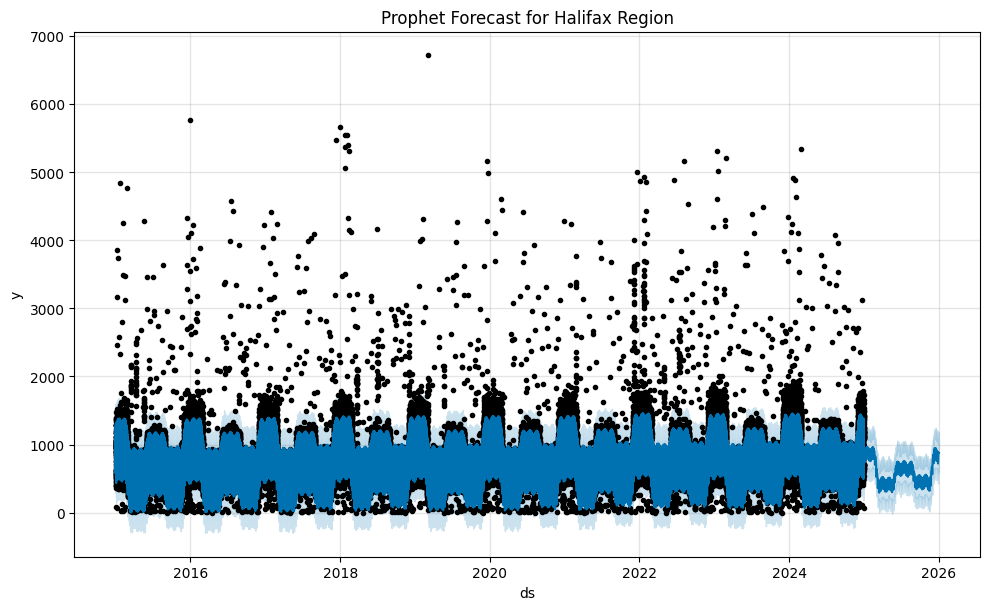

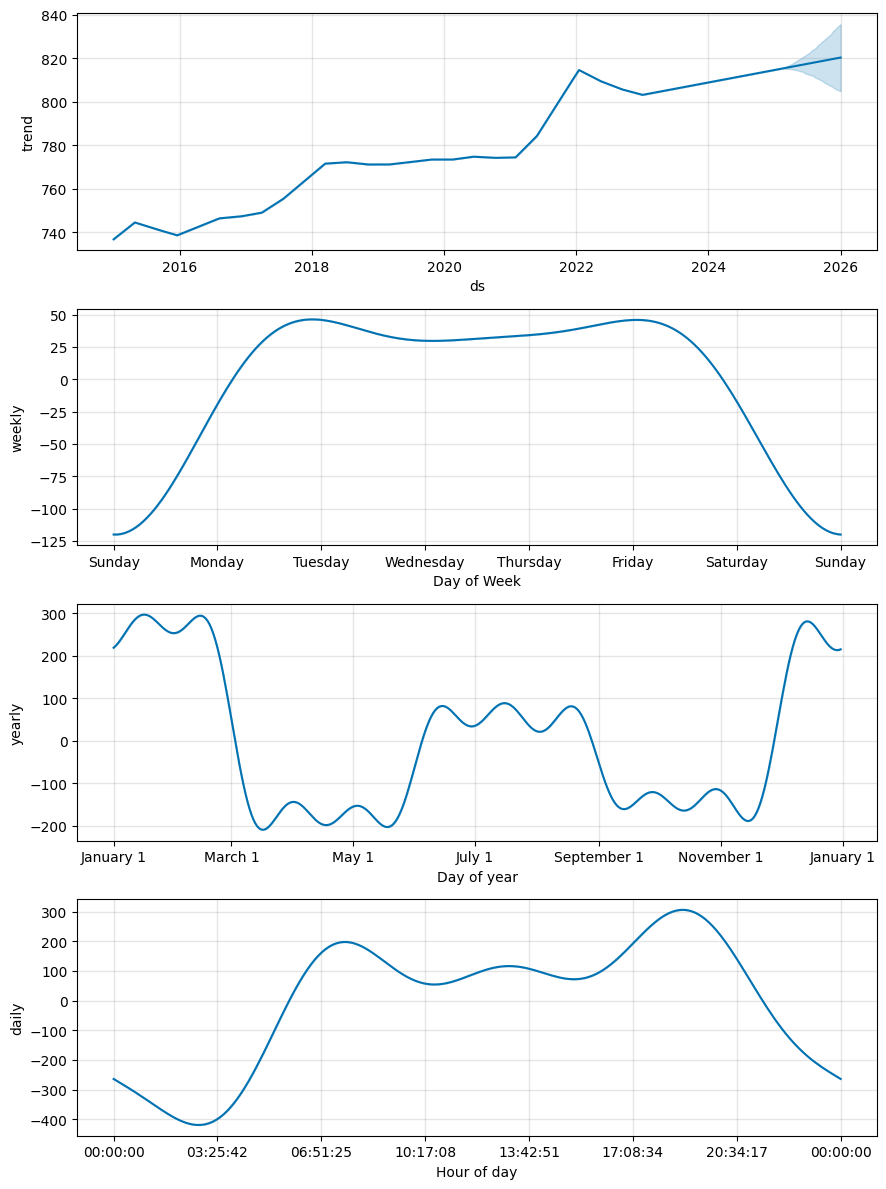

In [6]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast for Halifax Region")
plt.show()

# Plot forecast components
fig2 = model.plot_components(forecast)
plt.show()
